In [1]:
import matplotlib.pylab as plt
import numpy as np

In [2]:
class BanditArm:
    def __init__(self,m):
        self.m=m
        self.m_estimate=0
        self.N=0
        
    def pull(self):
        return np.random.randn() +self.m
    
    def update(self,x):
        self.N=self.N+1
        self.m_estimate=(1-1/self.N)*self.m_estimate +1/self.N*x
    

In [5]:
def run_expriment(m1,m2,m3,eps,N):
    bandits = [BanditArm(m1),BanditArm(m2),BanditArm(m3)]
    means=np.array([m1,m2,m3])
    ture_best=np.argmax(means)
    count_suboptimal=0
    data=np.empty(N)
    
    for i in range (N):
        p=np.random.random()
        if p <eps:
            j= np.random.choice(len(bandits))
        else:
            j=np.argmax([b.m_estimate for b in bandits])
     
        x=bandits[j].pull()
        bandits[j].update(x)
    
        if j!= ture_best:
            count_suboptimal +=1
        
        data[i]=x
    cumulative_average= np.cumsum(data)/(np.arange(N)+1)

    
    plt.plot(cumulative_average)
    plt.plot(np.ones(N)*m1)
    plt.plot(np.ones(N)*m2)
    plt.plot(np.ones(N)*m3)
    plt.xscale('log')
    plt.show()
    
    for b in bandits:
        print(b.m_estimate)
        
    print('percent suboptimal for epsilon= %s:' %eps, float(count_suboptimal)/N)
    
    return cumulative_average

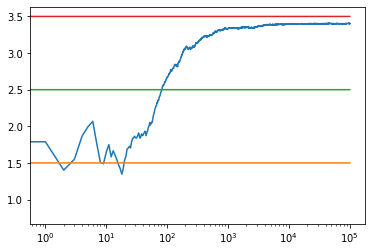

1.5035842648157833
2.490893035869057
3.504024815889074
percent suboptimal for epsilon= 0.1: 0.06693


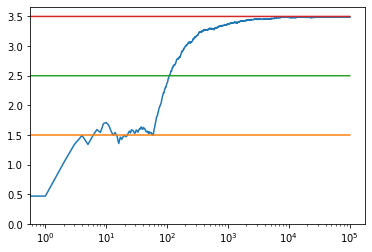

1.5055167884878364
2.5077775656977592
3.5012517715959093
percent suboptimal for epsilon= 0.01: 0.00685


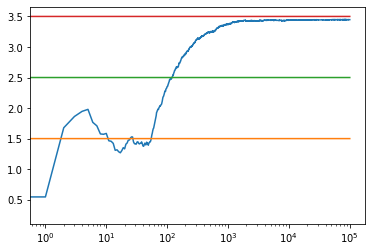

1.518119971817666
2.4876898758179666
3.4990161415602694
percent suboptimal for epsilon= 0.05: 0.03436


In [7]:
if __name__ == '__main__':
    m1,m2,m3= 1.5,2.5,3.5
    c_1=run_expriment(m1,m2,m3,.1,100000)
    c_01=run_expriment(m1,m2,m3,.01,100000)
    c_05=run_expriment(m1,m2,m3,.05,100000)
    

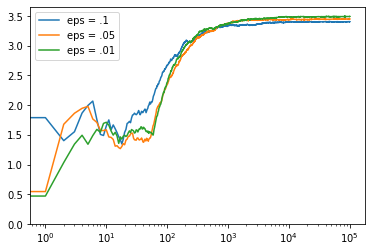

In [8]:
plt.plot(c_1,label='eps = .1')
plt.plot(c_05,label='eps = .05')
plt.plot(c_01,label='eps = .01')
plt.legend()
plt.xscale('log')
plt.show()

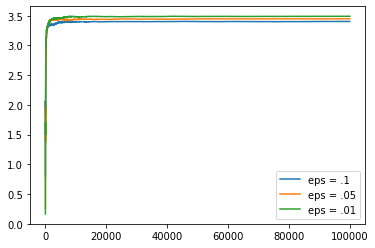

In [9]:
plt.plot(c_1,label='eps = .1')
plt.plot(c_05,label='eps = .05')
plt.plot(c_01,label='eps = .01')
plt.legend()
plt.show()